# Risk Metrics — Code Companion

This notebook demonstrates the functions in `risk_metrics.py` with live portfolio data.

- **Methodology:** `documentation/risk_metrics_methodology.md` — formulas, derivations, and interpretation

**Sections**
1. Setup
2. Portfolio Return Distribution
3. Value at Risk (VaR)
   - 3.1 Historical simulation
   - 3.2 Parametric (variance-covariance)
   - 3.3 Historical vs parametric comparison
4. Conditional VaR (CVaR / Expected Shortfall)
5. Component VaR — Euler decomposition

## 1. Setup

In [20]:
from utils import setup_repo_root

repo_root = setup_repo_root()
print("Working directory:", repo_root)

Working directory: /home/martin/python/risk-assessment


In [21]:
from typing import cast

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.container import BarContainer
from matplotlib.ticker import FuncFormatter
from scipy.stats import norm

from data_loader import clean_prices, load_positions, load_prices
from risk_metrics import (
    compute_component_var,
    compute_cvar_historical,
    compute_cvar_parametric,
    compute_var_historical,
    compute_var_parametric,
)

plt.rcParams.update({
    "figure.dpi": 120,
    "figure.figsize": (12, 4),
    "axes.spines.top": False,
    "axes.spines.right": False,
})
pd.set_option("display.float_format", "{:.6f}".format)

In [28]:
# Load positions and compute daily portfolio returns
positions = load_positions()
prices_raw = load_prices()
prices_clean = clean_prices(prices_raw)

prices_wide = (
    prices_clean
    .pivot(index="date", columns="instrument_id", values="price")
    .sort_index()
)
returns = prices_wide.pct_change().dropna(how="all")

weights = positions.set_index("instrument_id")["weight"]
common = returns.columns.intersection(weights.index)
port_returns = returns[common].dot(weights[common])

print(f"Portfolio return series: {len(port_returns)} days")
print(f"  {port_returns.index.min().date()} → {port_returns.index.max().date()}")
print(f"  mean={port_returns.mean():.4%}  std={port_returns.std():.4%}")

Portfolio return series: 252 days
  2025-04-01 → 2026-03-18
  mean=-0.0202%  std=0.6250%


## 2. Portfolio Return Distribution
*Methodology: `risk_metrics_methodology.md` section 1*

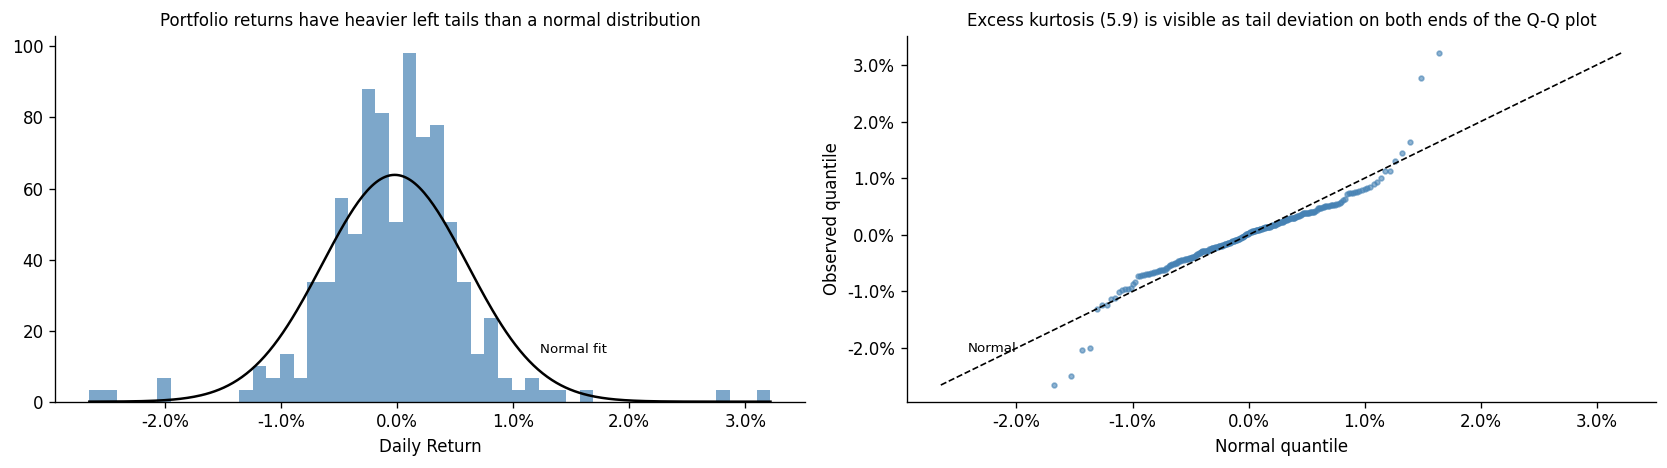

Skewness:        0.185  (0 = symmetric)
Excess kurtosis: 5.936  (0 = normal tails, >0 = fatter tails)


In [29]:
mu = port_returns.mean()
sigma = port_returns.std()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Left: histogram + fitted normal
ax = axes[0]
ax.hist(port_returns, bins=50, density=True, color="steelblue",
        edgecolor="none", alpha=0.7)
x = np.linspace(port_returns.min(), port_returns.max(), 300)
ax.plot(x, norm.pdf(x, mu, sigma), color="black", linewidth=1.5)
# Direct label on the normal curve
x_lbl = mu + 2.0 * sigma
y_lbl = norm.pdf(x_lbl, mu, sigma) + norm.pdf(mu, mu, sigma) * 0.08
ax.text(x_lbl, y_lbl, "Normal fit", fontsize=8, color="black", ha="left")
ax.set_title("Portfolio returns have heavier left tails than a normal distribution",
             fontsize=10)
ax.set_xlabel("Daily Return")
ax.xaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v:.1%}"))

# Right: QQ-plot
ax2 = axes[1]
sorted_obs = np.sort(port_returns)
n = len(sorted_obs)
theoretical = norm.ppf(np.arange(1, n + 1) / (n + 1), mu, sigma)
ax2.scatter(theoretical, sorted_obs, s=8, color="steelblue", alpha=0.6)
lims = [min(theoretical.min(), sorted_obs.min()), max(theoretical.max(), sorted_obs.max())]
ax2.plot(lims, lims, color="black", linewidth=1, linestyle="--")
# Direct label on diagonal line
span = lims[1] - lims[0]
ax2.text(lims[0] + span * 0.04, lims[0] + span * 0.10,
         "Normal", fontsize=8, color="black", ha="left")
ax2.set_title(
    "Excess kurtosis (5.9) is visible as tail deviation on both ends of the Q-Q plot",
    fontsize=10,
)
ax2.set_xlabel("Normal quantile")
ax2.set_ylabel("Observed quantile")
ax2.xaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v:.1%}"))
ax2.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v:.1%}"))

plt.tight_layout()
plt.show()

print(f"Skewness:        {port_returns.skew():.3f}  (0 = symmetric)")
print(f"Excess kurtosis: {port_returns.kurt():.3f}  (0 = normal tails, >0 = fatter tails)")

## 3. Value at Risk (VaR)
*Methodology: `risk_metrics_methodology.md` section 2*

### 3.1 Historical simulation
*Methodology: `risk_metrics_methodology.md` section 2.1*

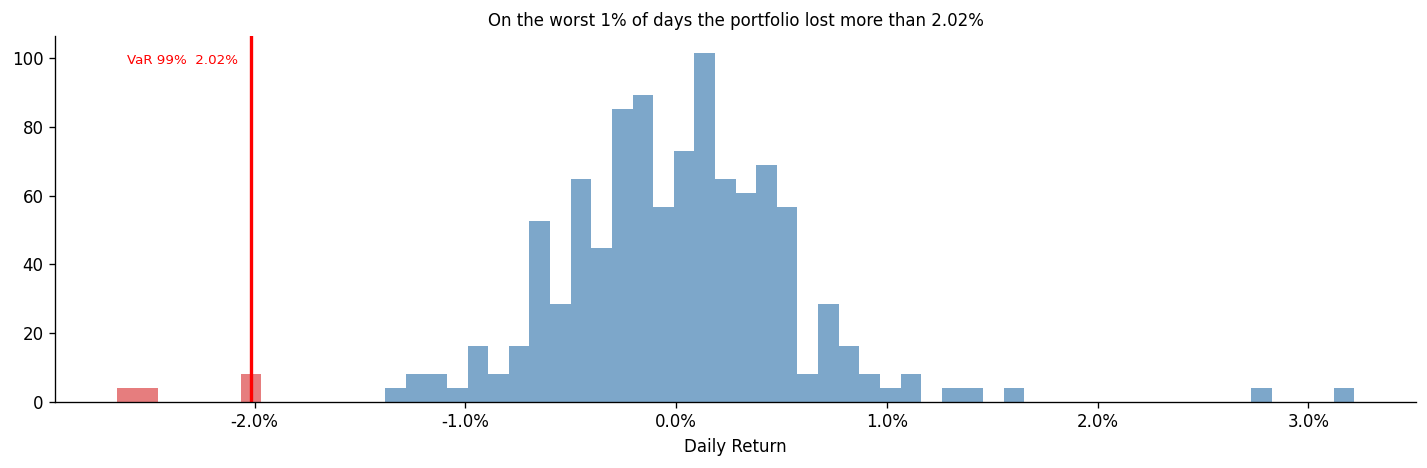

Historical VaR 99%: 2.0153%

Interpretation: on 99% of days losses should not exceed 2.02% of portfolio value.


In [30]:
var_hist_99 = compute_var_historical(port_returns, confidence=0.99)

fig, ax = plt.subplots(figsize=(12, 4))

_, bins, patches = ax.hist(
    port_returns, bins=60, density=True,
    color="steelblue", edgecolor="none", alpha=0.7,
)
for patch, left in zip(cast(BarContainer, patches), bins[:-1], strict=True):
    if left < -var_hist_99:
        patch.set_facecolor("tab:red")
        patch.set_alpha(0.6)

ax.axvline(-var_hist_99, color="red", linewidth=2)

# Direct annotation on VaR line
y_top = ax.get_ylim()[1]
x_off = (ax.get_xlim()[1] - ax.get_xlim()[0]) * 0.01
ax.text(-var_hist_99 - x_off, y_top * 0.95,
        f"VaR 99%  {var_hist_99:.2%}", ha="right", va="top", fontsize=8, color="red")

ax.set_title(f"On the worst 1% of days the portfolio lost more than {var_hist_99:.2%}",
             fontsize=10)
ax.set_xlabel("Daily Return")
ax.xaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v:.1%}"))
plt.tight_layout()
plt.show()

print(f"Historical VaR 99%: {var_hist_99:.4%}")
print()
print("Interpretation: on 99% of days losses should not exceed",
      f"{var_hist_99:.2%} of portfolio value.")

### 3.2 Parametric (variance-covariance)
*Methodology: `risk_metrics_methodology.md` section 2.2*

Parametric VaR 99%: 1.4741%


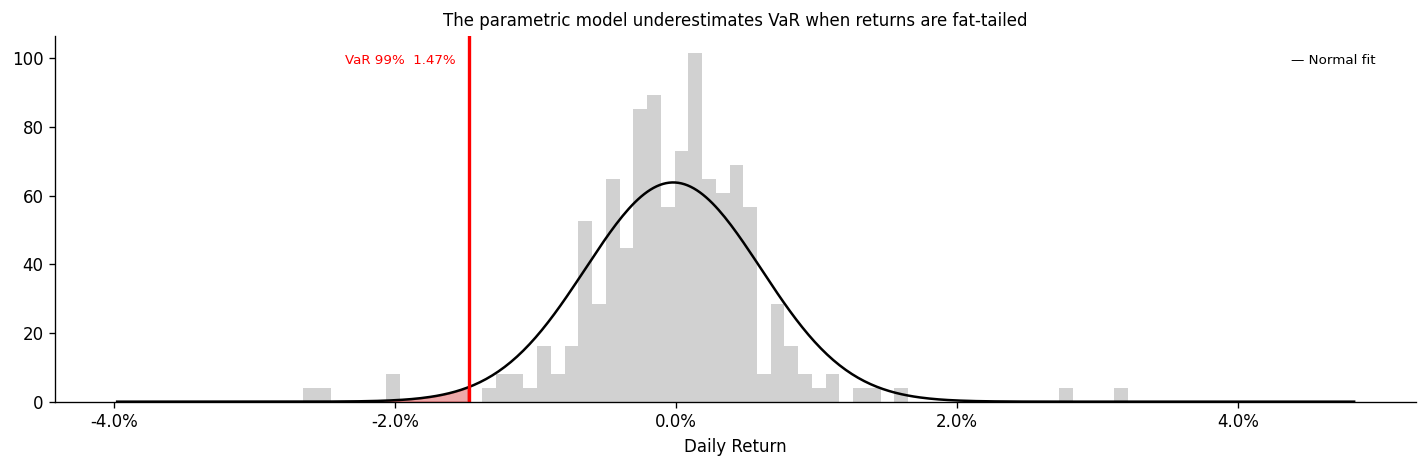

In [24]:
var_param_99 = compute_var_parametric(port_returns, confidence=0.99)

print(f"Parametric VaR 99%: {var_param_99:.4%}")

fig, ax = plt.subplots(figsize=(12, 4))
x = np.linspace(port_returns.min() * 1.5, port_returns.max() * 1.5, 400)

# Grey histogram as context — focus stays on the normal curve
ax.hist(port_returns, bins=60, density=True, color="#cccccc", edgecolor="none", alpha=0.9)
ax.plot(x, norm.pdf(x, mu, sigma), color="black", linewidth=1.5)

x_tail = x[x <= -var_param_99]
ax.fill_between(x_tail, norm.pdf(x_tail, mu, sigma), color="tab:red", alpha=0.4)

ax.axvline(-var_param_99, color="red", linewidth=2)

# Direct annotations
y_top = ax.get_ylim()[1]
x_off = (ax.get_xlim()[1] - ax.get_xlim()[0]) * 0.01
ax.text(-var_param_99 - x_off, y_top * 0.95,
        f"VaR 99%  {var_param_99:.2%}", ha="right", va="top", fontsize=8, color="red")
ax.text(0.97, 0.95, "— Normal fit", transform=ax.transAxes,
        ha="right", va="top", fontsize=8, color="black")

ax.set_title("The parametric model underestimates VaR when returns are fat-tailed",
             fontsize=10)
ax.set_xlabel("Daily Return")
ax.xaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v:.1%}"))
plt.tight_layout()
plt.show()

### 3.3 Historical vs parametric comparison
*Methodology: `risk_metrics_methodology.md` section 2.3*

In [25]:
comparison = pd.DataFrame(
    {
        "Historical": [
            compute_var_historical(port_returns, 0.90),
            compute_var_historical(port_returns, 0.95),
            compute_var_historical(port_returns, 0.99),
        ],
        "Parametric": [
            compute_var_parametric(port_returns, 0.90),
            compute_var_parametric(port_returns, 0.95),
            compute_var_parametric(port_returns, 0.99),
        ],
    },
    index=["90%", "95%", "99%"],
)
comparison["Difference"] = comparison["Historical"] - comparison["Parametric"]

diff_99 = comparison.loc["99%", "Difference"]
print(f"At 99% confidence, historical VaR exceeds parametric by {diff_99:.2%} — fat tails matter.")
print()

display(comparison.style.format({
    "Historical": "{:.4%}",
    "Parametric": "{:.4%}",
    "Difference": "{:.4%}",
}))

At 99% confidence, historical VaR exceeds parametric by 0.54% — fat tails matter.



,Historical,Parametric,Difference
90%,0.6617%,0.8211%,-0.1595%
95%,0.9463%,1.0482%,-0.1018%
99%,2.0153%,1.4741%,0.5412%


## 4. Conditional VaR (CVaR) — Expected Shortfall
*Methodology: `risk_metrics_methodology.md` section 3*

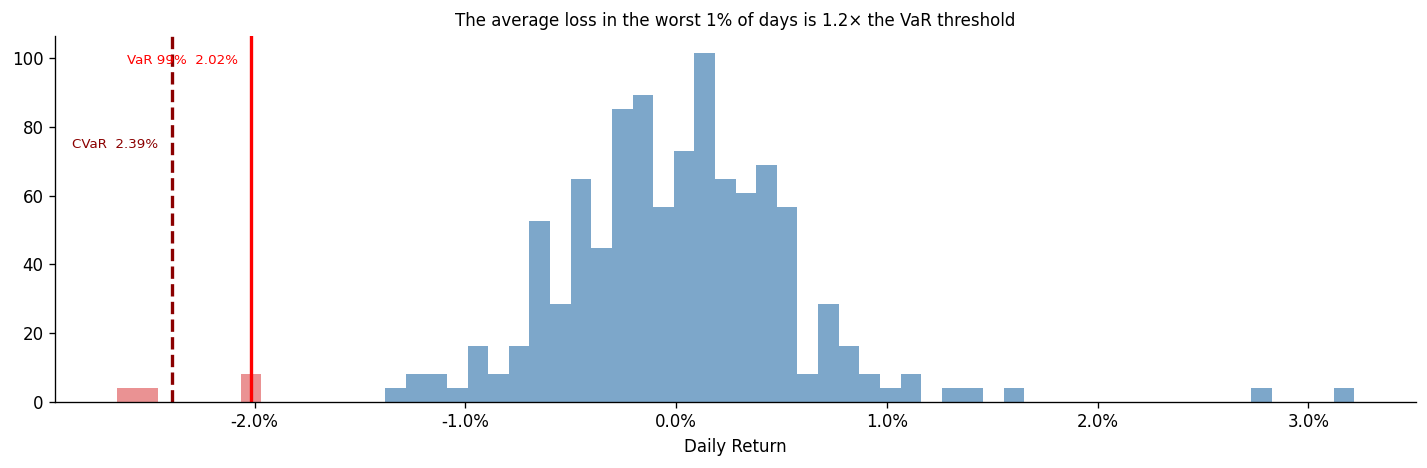

VaR  99% (historical):  2.0153%   ← loss threshold
CVaR 99% (historical):  2.3921%   ← average loss given we are in the tail

CVaR/VaR ratio (hist):  1.19x
Tail observations used: 3 days


In [16]:
cvar_hist_99  = compute_cvar_historical(port_returns, 0.99)

tail_obs = port_returns[port_returns < -var_hist_99]

fig, ax = plt.subplots(figsize=(12, 4))

_, bins, patches = ax.hist(
    port_returns, bins=60, density=True,
    color="steelblue", edgecolor="none", alpha=0.7,
)
for patch, left in zip(cast(BarContainer, patches), bins[:-1], strict=True):
    if left < -var_hist_99:
        patch.set_facecolor("tab:red")
        patch.set_alpha(0.5)

ax.axvline(-var_hist_99, color="red", linewidth=2)
ax.axvline(-cvar_hist_99, color="darkred", linewidth=2, linestyle="--")

# Direct annotations — staggered vertically to avoid overlap
y_top = ax.get_ylim()[1]
x_off = (ax.get_xlim()[1] - ax.get_xlim()[0]) * 0.01
ax.text(-var_hist_99 - x_off, y_top * 0.95,
        f"VaR 99%  {var_hist_99:.2%}", ha="right", va="top", fontsize=8, color="red")
ax.text(-cvar_hist_99 - x_off, y_top * 0.72,
        f"CVaR  {cvar_hist_99:.2%}", ha="right", va="top", fontsize=8, color="darkred")

ratio = cvar_hist_99 / var_hist_99
ax.set_title(
    f"The average loss in the worst 1% of days is {ratio:.1f}× the VaR threshold",
    fontsize=10,
)
ax.set_xlabel("Daily Return")
ax.xaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v:.1%}"))
plt.tight_layout()
plt.show()

print(f"VaR  99% (historical):  {var_hist_99:.4%}   ← loss threshold")
print(f"CVaR 99% (historical):  {cvar_hist_99:.4%}   ← average loss given we are in the tail")
print()
print(f"CVaR/VaR ratio (hist):  {cvar_hist_99/var_hist_99:.2f}x")
print(f"Tail observations used: {len(tail_obs)} days")

### Parametric CVaR formula
*Methodology: `risk_metrics_methodology.md` section 3.1*

In [26]:
cvar_param_99 = compute_cvar_parametric(port_returns, confidence=0.99)

print(f"CVaR 99% (parametric): {cvar_param_99:.4%}")
print()
print(f"CVaR/VaR ratio (param): {cvar_param_99/var_param_99:.2f}x")

CVaR 99% (parametric): 1.6858%

CVaR/VaR ratio (param): 1.14x


## 5. Component VaR — Euler Decomposition
*Methodology: `risk_metrics_methodology.md` section 4*

In [27]:
weights_arr = positions.set_index("instrument_id").loc[common, "weight"].to_numpy()
cov_matrix  = returns[common].cov().values

comp_var = compute_component_var(weights_arr, cov_matrix, confidence=0.99)

port_vol  = float(np.sqrt(weights_arr @ cov_matrix @ weights_arr))
total_var = port_vol * norm.ppf(0.99)

print(f"Portfolio volatility (daily): {port_vol:.4%}")
print(f"Total parametric VaR 99%:     {total_var:.4%}")
print(f"Sum of component VaRs:        {comp_var.sum():.4%}  ← must equal total VaR")
print(f"Difference:                   {abs(comp_var.sum() - total_var):.2e}  (rounding only)")

comp_df = (
    pd.DataFrame({"instrument_id": common, "component_var": comp_var})
    .merge(positions[["instrument_id", "weight", "sub_class"]], on="instrument_id")
    .assign(pct_of_total=lambda df: df["component_var"] / total_var)
    .sort_values("component_var", ascending=False)
    .reset_index(drop=True)
)
comp_df[["instrument_id", "sub_class", "weight", "component_var", "pct_of_total"]]

Portfolio volatility (daily): 0.6250%
Total parametric VaR 99%:     1.4539%
Sum of component VaRs:        1.4539%  ← must equal total VaR
Difference:                   3.47e-18  (rounding only)


,instrument_id,sub_class,weight,component_var,pct_of_total
0,NOVN,SWISS_EQUITY,0.055000,0.001970,0.135512
1,ROG,SWISS_EQUITY,0.050000,0.001954,0.134402
2,UBSG,SWISS_EQUITY,0.035000,0.001856,0.127663
3,ASML_NA,EUR_EQUITY,0.025000,0.001629,0.112060
4,NESN,SWISS_EQUITY,0.060000,0.001546,0.106338
5,ABBN,SWISS_EQUITY,0.030000,0.001298,0.089307
6,SIE_GR,EUR_EQUITY,0.025000,0.001136,0.078147
7,SAN_FP,EUR_EQUITY,0.030000,0.001124,0.077280
8,SREN,SWISS_EQUITY,0.020000,0.000932,0.064111
9,ALV_GR,EUR_EQUITY,0.020000,0.000857,0.058926


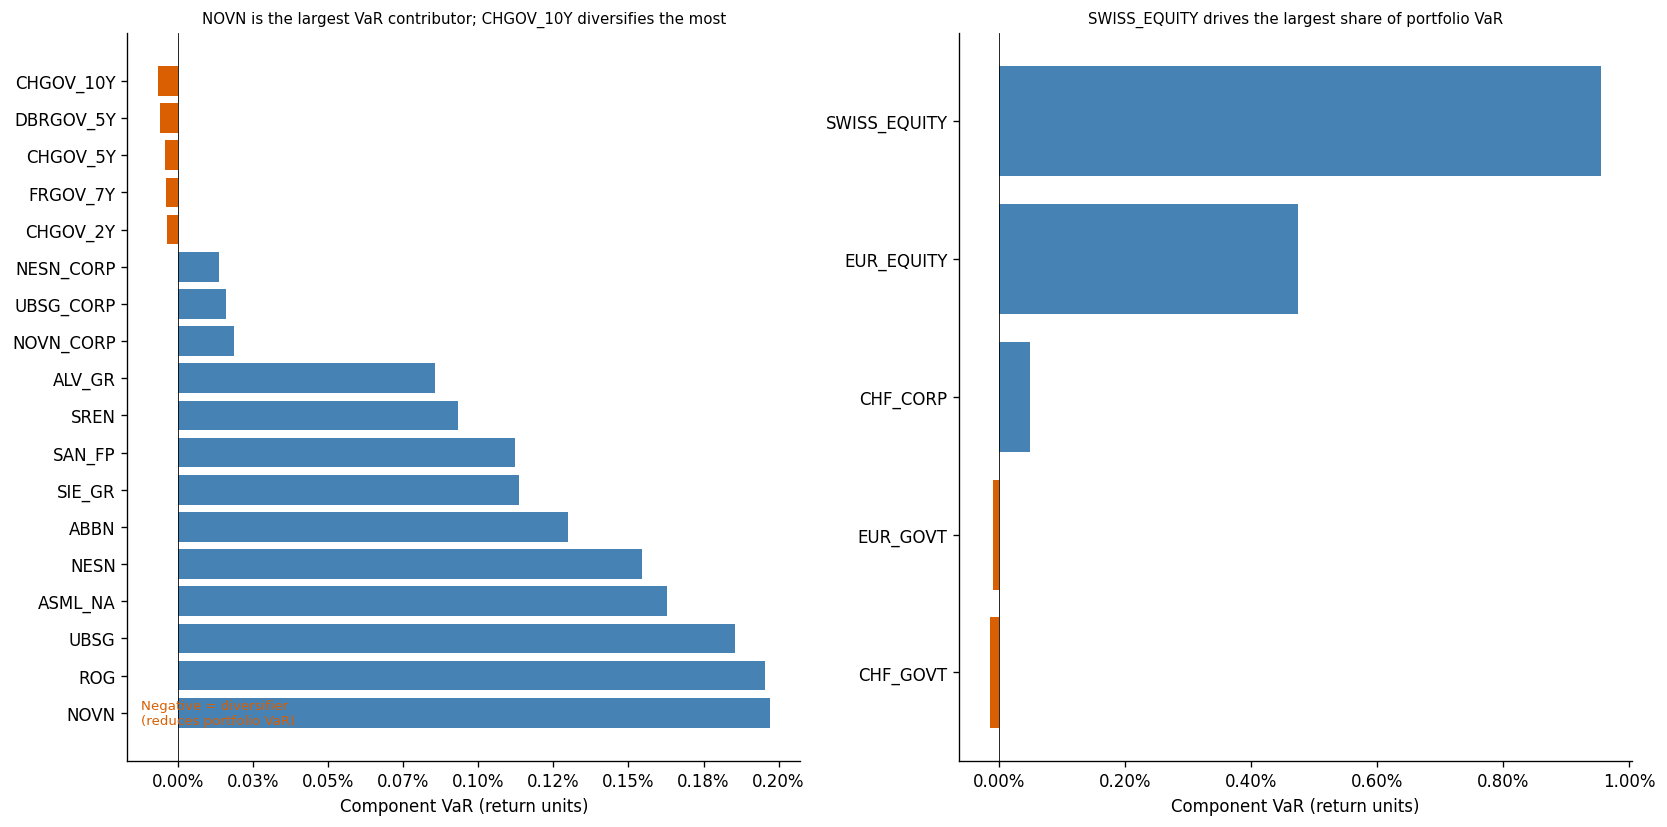

Positions with negative component VaR act as portfolio diversifiers:
  their returns tend to be high when the portfolio loses — they offset risk.


In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 7))

# Left: component VaR by instrument
ax = axes[0]
colors = ["#d95f02" if v < 0 else "steelblue" for v in comp_df["component_var"]]
ax.barh(comp_df["instrument_id"], comp_df["component_var"], color=colors)
ax.axvline(0, color="black", linewidth=0.5)
top_inst = comp_df.iloc[0]["instrument_id"]
bot_inst = comp_df.iloc[-1]["instrument_id"]
ax.set_title(f"{top_inst} is the largest VaR contributor; {bot_inst} diversifies the most",
             fontsize=9)
ax.set_xlabel("Component VaR (return units)")
ax.xaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v:.2%}"))
ax.annotate("Negative = diversifier\n(reduces portfolio VaR)",
            xy=(0.02, 0.05), xycoords="axes fraction", fontsize=8, color="#d95f02")

# Right: component VaR by sub-class (horizontal bars — consistent with left panel)
ax2 = axes[1]
sub_class_var = comp_df.groupby("sub_class")["component_var"].sum()
top_sc = sub_class_var.idxmax()
sub_class_var_sorted = sub_class_var.sort_values()
colors_sc = ["#d95f02" if v < 0 else "steelblue" for v in sub_class_var_sorted]
ax2.barh(sub_class_var_sorted.index, sub_class_var_sorted.values, color=colors_sc)
ax2.axvline(0, color="black", linewidth=0.5)
ax2.set_title(f"{top_sc} drives the largest share of portfolio VaR", fontsize=9)
ax2.set_xlabel("Component VaR (return units)")
ax2.xaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v:.2%}"))

plt.tight_layout()
plt.show()

print("Positions with negative component VaR act as portfolio diversifiers:")
print("  their returns tend to be high when the portfolio loses — they offset risk.")